In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil, time
from pathlib import Path

DRIVE_DATA = Path('/content/drive/MyDrive/MLGroup/emotion/data')
LOCAL_DATA = Path('/content/fer2013')

print('Drive contents:', os.listdir(DRIVE_DATA))

# Copy dataset from Drive (slow per-file FUSE) to local disk (fast).
# Without this, each batch reads images through Google Drive over the
# network and the GPU sits idle waiting for I/O — a single epoch can take
# 20-40 minutes. One-off copy takes ~3-5 min; later runs in the same
# session skip it because the folder already exists.
if not (LOCAL_DATA / 'train' / 'happy').exists():
    t0 = time.time()
    print('Copying dataset from Drive to /content/fer2013 ...')
    shutil.copytree(DRIVE_DATA / 'train', LOCAL_DATA / 'train')
    shutil.copytree(DRIVE_DATA / 'test',  LOCAL_DATA / 'test')
    print(f'Copy finished in {time.time()-t0:.1f}s')
else:
    print('Local copy already exists; skipping.')

print('Local contents:', os.listdir(LOCAL_DATA))

Drive contents: ['test', 'train', 'fer2013']
Copying dataset from Drive to /content/fer2013 ...
Copy finished in 724.3s
Local contents: ['train', 'test']


In [ ]:
!pip install -q scikit-learn matplotlib seaborn

In [ ]:
import json, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
)

In [ ]:
# Dataset reads come from the local copy made in the cell above.
# Model weights and reports still write to Drive so they survive a Colab
# disconnect (small number of large files — Drive handles that fine; it
# was only the per-image reads that were slow).
TRAIN_DIR   = LOCAL_DATA / 'train'
TEST_DIR    = LOCAL_DATA / 'test'
OUT_DIR     = Path('/content/drive/MyDrive/MLGroup/emotion/sanija-emotion')
MODELS_DIR  = OUT_DIR / 'models'
REPORTS_DIR = OUT_DIR / 'reports'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = len(CLASSES)

IMG_SIZE        = 128
BATCH_SIZE      = 64
EPOCHS_PHASE1   = 8
EPOCHS_PHASE2   = 17
LR_PHASE1       = 1e-3
LR_PHASE2       = 1e-5
LABEL_SMOOTHING = 0.05
VAL_SPLIT       = 0.10
SEED            = 42
TAG             = 'resnet18'

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
    ),
    transforms.ColorJitter(brightness=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
full_train_aug  = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_tf)
full_train_eval = datasets.ImageFolder(root=str(TRAIN_DIR), transform=eval_tf)
test_data       = datasets.ImageFolder(root=str(TEST_DIR),  transform=eval_tf)

assert list(full_train_aug.class_to_idx.keys()) == CLASSES, (
    f'Class order mismatch.\n  on disk: {list(full_train_aug.class_to_idx.keys())}\n'
    f'  config : {CLASSES}'
)

n_total = len(full_train_aug)
n_val   = int(round(n_total * VAL_SPLIT))
perm    = np.random.RandomState(SEED).permutation(n_total)
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_data = Subset(full_train_aug,  train_idx.tolist())
val_data   = Subset(full_train_eval, val_idx.tolist())

print(f'train: {len(train_data)}  val: {len(val_data)}  test: {len(test_data)}')

train: 25838  val: 2871  test: 7178


In [ ]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
def build_resnet18(num_classes: int = NUM_CLASSES) -> nn.Module:
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

def freeze_backbone(model: nn.Module) -> None:
    for name, child in model.named_children():
        set_requires_grad(child, name == 'fc')

def unfreeze_last_stage(model: nn.Module) -> None:
    for name, child in model.named_children():
        set_requires_grad(child, name in {'layer4', 'fc'})

def freeze_bn_running_stats(model: nn.Module) -> None:
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            if not any(p.requires_grad for p in m.parameters(recurse=False)):
                m.eval()

def count_trainable(model: nn.Module) -> tuple[int, int]:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total

In [ ]:
model = build_resnet18().to(device)
freeze_backbone(model)
tr, tot = count_trainable(model)
print(f'Phase 1 trainable params: {tr:,} / {tot:,} ({100*tr/tot:.2f}%)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 85.7MB/s]


Phase 1 trainable params: 3,591 / 11,180,103 (0.03%)


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(mode=train_mode)
    if train_mode:
        freeze_bn_running_stats(model)

    total_loss, total_correct, total_n = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(images)
                loss = criterion(outputs, labels)

        bs = labels.size(0)
        total_loss    += loss.item() * bs
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_n       += bs

    return total_loss / total_n, total_correct / total_n


def train_phase(model, optimizer, criterion, n_epochs, phase, start_epoch,
                history, best_val_acc, best_path):
    for epoch in range(start_epoch, start_epoch + n_epochs):
        t0 = time.time()
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)
        dt = time.time() - t0

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)

        print(
            f'[{phase}] epoch {epoch:02d}  '
            f'train_loss={train_loss:.4f} acc={train_acc:.4f}  '
            f'val_loss={val_loss:.4f} acc={val_acc:.4f}  '
            f'({dt:.1f}s)' + ('  *best*' if improved else '')
        )
    return best_val_acc

In [ ]:
best_path = MODELS_DIR / f'{TAG}_best.pth'
history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
best_val_acc = 0.0

print(f'\nPhase 1: head only, lr={LR_PHASE1}')
freeze_backbone(model)
tr, tot = count_trainable(model)
print(f'Trainable params: {tr:,} / {tot:,} ({100*tr/tot:.2f}%)')
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR_PHASE1)
best_val_acc = train_phase(
    model, optimizer, criterion,
    n_epochs=EPOCHS_PHASE1, phase='p1', start_epoch=1,
    history=history, best_val_acc=best_val_acc, best_path=best_path,
)

print(f'\nPhase 2: unfreeze layer4+fc, lr={LR_PHASE2}')
unfreeze_last_stage(model)
tr, tot = count_trainable(model)
print(f'Trainable params: {tr:,} / {tot:,} ({100*tr/tot:.2f}%)')
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR_PHASE2)
best_val_acc = train_phase(
    model, optimizer, criterion,
    n_epochs=EPOCHS_PHASE2, phase='p2', start_epoch=EPOCHS_PHASE1 + 1,
    history=history, best_val_acc=best_val_acc, best_path=best_path,
)

print(f'\nBest val accuracy: {best_val_acc:.4f}')
print(f'Best weights saved to: {best_path}')


Phase 1: head only, lr=0.001
Trainable params: 3,591 / 11,180,103 (0.03%)
[p1] epoch 01  train_loss=1.7201 acc=0.3459  val_loss=1.5776 acc=0.4274  (61.2s)  *best*
[p1] epoch 02  train_loss=1.6270 acc=0.3925  val_loss=1.5637 acc=0.4274  (41.9s)
[p1] epoch 03  train_loss=1.6210 acc=0.3916  val_loss=1.5356 acc=0.4343  (42.8s)  *best*
[p1] epoch 04  train_loss=1.6182 acc=0.3966  val_loss=1.5451 acc=0.4361  (41.6s)  *best*
[p1] epoch 05  train_loss=1.6191 acc=0.3988  val_loss=1.5707 acc=0.4284  (43.6s)
[p1] epoch 06  train_loss=1.6105 acc=0.4004  val_loss=1.5259 acc=0.4479  (42.2s)  *best*
[p1] epoch 07  train_loss=1.6158 acc=0.4005  val_loss=1.5444 acc=0.4274  (42.5s)
[p1] epoch 08  train_loss=1.6116 acc=0.4019  val_loss=1.5449 acc=0.4204  (41.9s)

Phase 2: unfreeze layer4+fc, lr=1e-05
Trainable params: 8,397,319 / 11,180,103 (75.11%)
[p2] epoch 09  train_loss=1.7372 acc=0.3806  val_loss=1.5066 acc=0.4720  (41.3s)  *best*
[p2] epoch 10  train_loss=1.5653 acc=0.4436  val_loss=1.4321 acc=0.

In [ ]:
with open(MODELS_DIR / f'{TAG}_history.json', 'w') as f:
    json.dump({
        'history': history,
        'phase1_epochs': EPOCHS_PHASE1,
        'phase2_epochs': EPOCHS_PHASE2,
    }, f, indent=2)

In [ ]:
def collect_predictions(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            ps.append(outputs.argmax(1).cpu().numpy())
            ys.append(labels.numpy())
    return np.concatenate(ys), np.concatenate(ps)

best_model = build_resnet18().to(device)
best_model.load_state_dict(torch.load(best_path, map_location=device))

y_true, y_pred = collect_predictions(best_model, test_loader)

metrics = {
    'accuracy':         float(accuracy_score(y_true, y_pred)),
    'macro_f1':         float(f1_score(y_true, y_pred, average='macro')),
    'weighted_f1':      float(f1_score(y_true, y_pred, average='weighted')),
    'per_class_f1':     f1_score(y_true, y_pred, average=None).tolist(),
    'confusion_matrix': confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))).tolist(),
}

print('Test accuracy   :', round(metrics['accuracy'],    4))
print('Test macro-F1   :', round(metrics['macro_f1'],    4))
print('Test weighted-F1:', round(metrics['weighted_f1'], 4))
print()
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

with open(REPORTS_DIR / f'{TAG}_test_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

Test accuracy   : 0.5876
Test macro-F1   : 0.5132
Test weighted-F1: 0.5758

              precision    recall  f1-score   support

       angry     0.4919    0.4781    0.4849       958
     disgust     0.6667    0.1261    0.2121       111
        fear     0.4491    0.3145    0.3699      1024
       happy     0.7468    0.8461    0.7933      1774
     neutral     0.5175    0.6464    0.5748      1233
         sad     0.4824    0.4274    0.4532      1247
    surprise     0.6944    0.7136    0.7039       831

    accuracy                         0.5876      7178
   macro avg     0.5784    0.5075    0.5132      7178
weighted avg     0.5777    0.5876    0.5758      7178



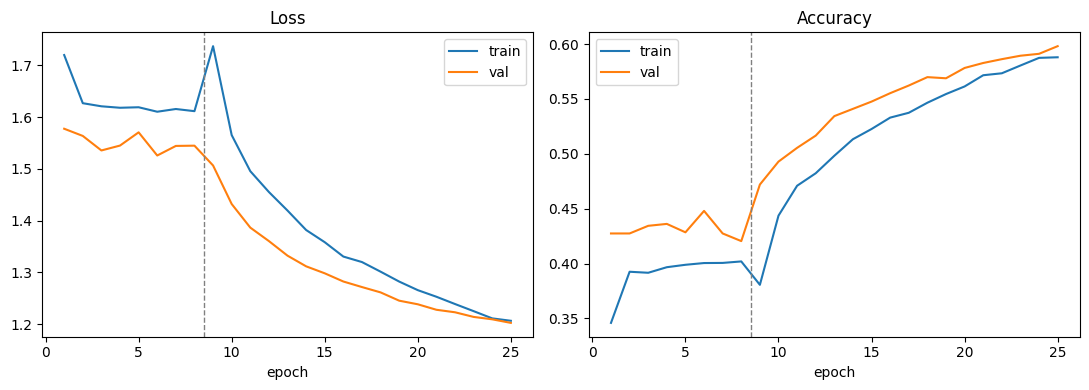

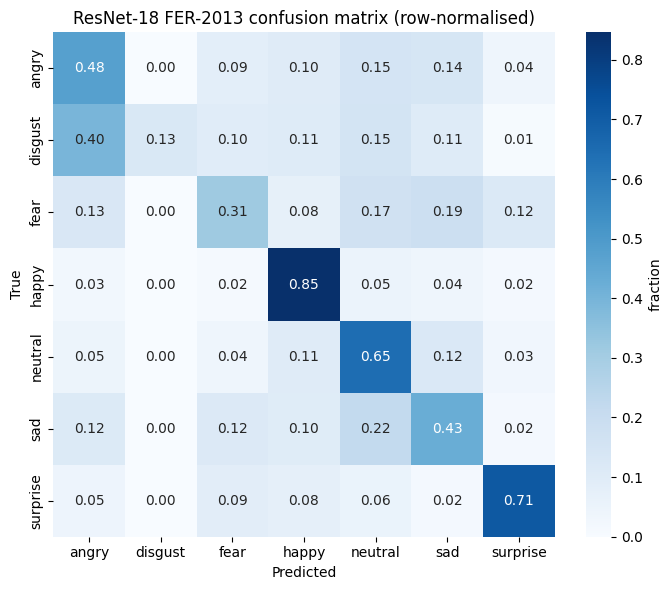

Saved:
  /content/drive/MyDrive/MLGroup/emotion/sanija-emotion/models/resnet18_best.pth
  /content/drive/MyDrive/MLGroup/emotion/sanija-emotion/models/resnet18_history.json
  /content/drive/MyDrive/MLGroup/emotion/sanija-emotion/reports/resnet18_test_metrics.json
  /content/drive/MyDrive/MLGroup/emotion/sanija-emotion/reports/resnet18_training_curves.png
  /content/drive/MyDrive/MLGroup/emotion/sanija-emotion/reports/resnet18_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

epochs = range(1, len(history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history['loss'],     label='train')
axes[0].plot(epochs, history['val_loss'], label='val')
axes[0].axvline(EPOCHS_PHASE1 + 0.5, linestyle='--', color='grey', linewidth=1)
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(epochs, history['accuracy'],     label='train')
axes[1].plot(epochs, history['val_accuracy'], label='val')
axes[1].axvline(EPOCHS_PHASE1 + 0.5, linestyle='--', color='grey', linewidth=1)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / f'{TAG}_training_curves.png', dpi=150)
plt.show()

cm = np.asarray(metrics['confusion_matrix'], dtype=np.float64)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums > 0)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
    cbar_kws={'label': 'fraction'},
)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('ResNet-18 FER-2013 confusion matrix (row-normalised)')
fig.tight_layout()
fig.savefig(REPORTS_DIR / f'{TAG}_confusion_matrix.png', dpi=150)
plt.show()

print('Saved:')
print(' ', best_path)
print(' ', MODELS_DIR  / f'{TAG}_history.json')
print(' ', REPORTS_DIR / f'{TAG}_test_metrics.json')
print(' ', REPORTS_DIR / f'{TAG}_training_curves.png')
print(' ', REPORTS_DIR / f'{TAG}_confusion_matrix.png')